In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Read the dataset
data = pd.read_csv("LoanApprovalPrediction.csv")





In [3]:
# Initial overview
print("First 5 rows:\n", data.head())
print("\nData Types:\n", data.dtypes)

# Drop Loan_ID
data.drop(columns=['Loan_ID'], inplace=True)



First 5 rows:
     Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No         0.0      Graduate            No   
1  LP001003   Male     Yes         1.0      Graduate            No   
2  LP001005   Male     Yes         0.0      Graduate           Yes   
3  LP001006   Male     Yes         0.0  Not Graduate            No   
4  LP001008   Male      No         0.0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  

In [4]:
# Show categorical variable count before encoding
cat_cols = data.select_dtypes(include='object').columns
print(f"Categorical variables before encoding: {len(cat_cols)}")



Categorical variables before encoding: 6


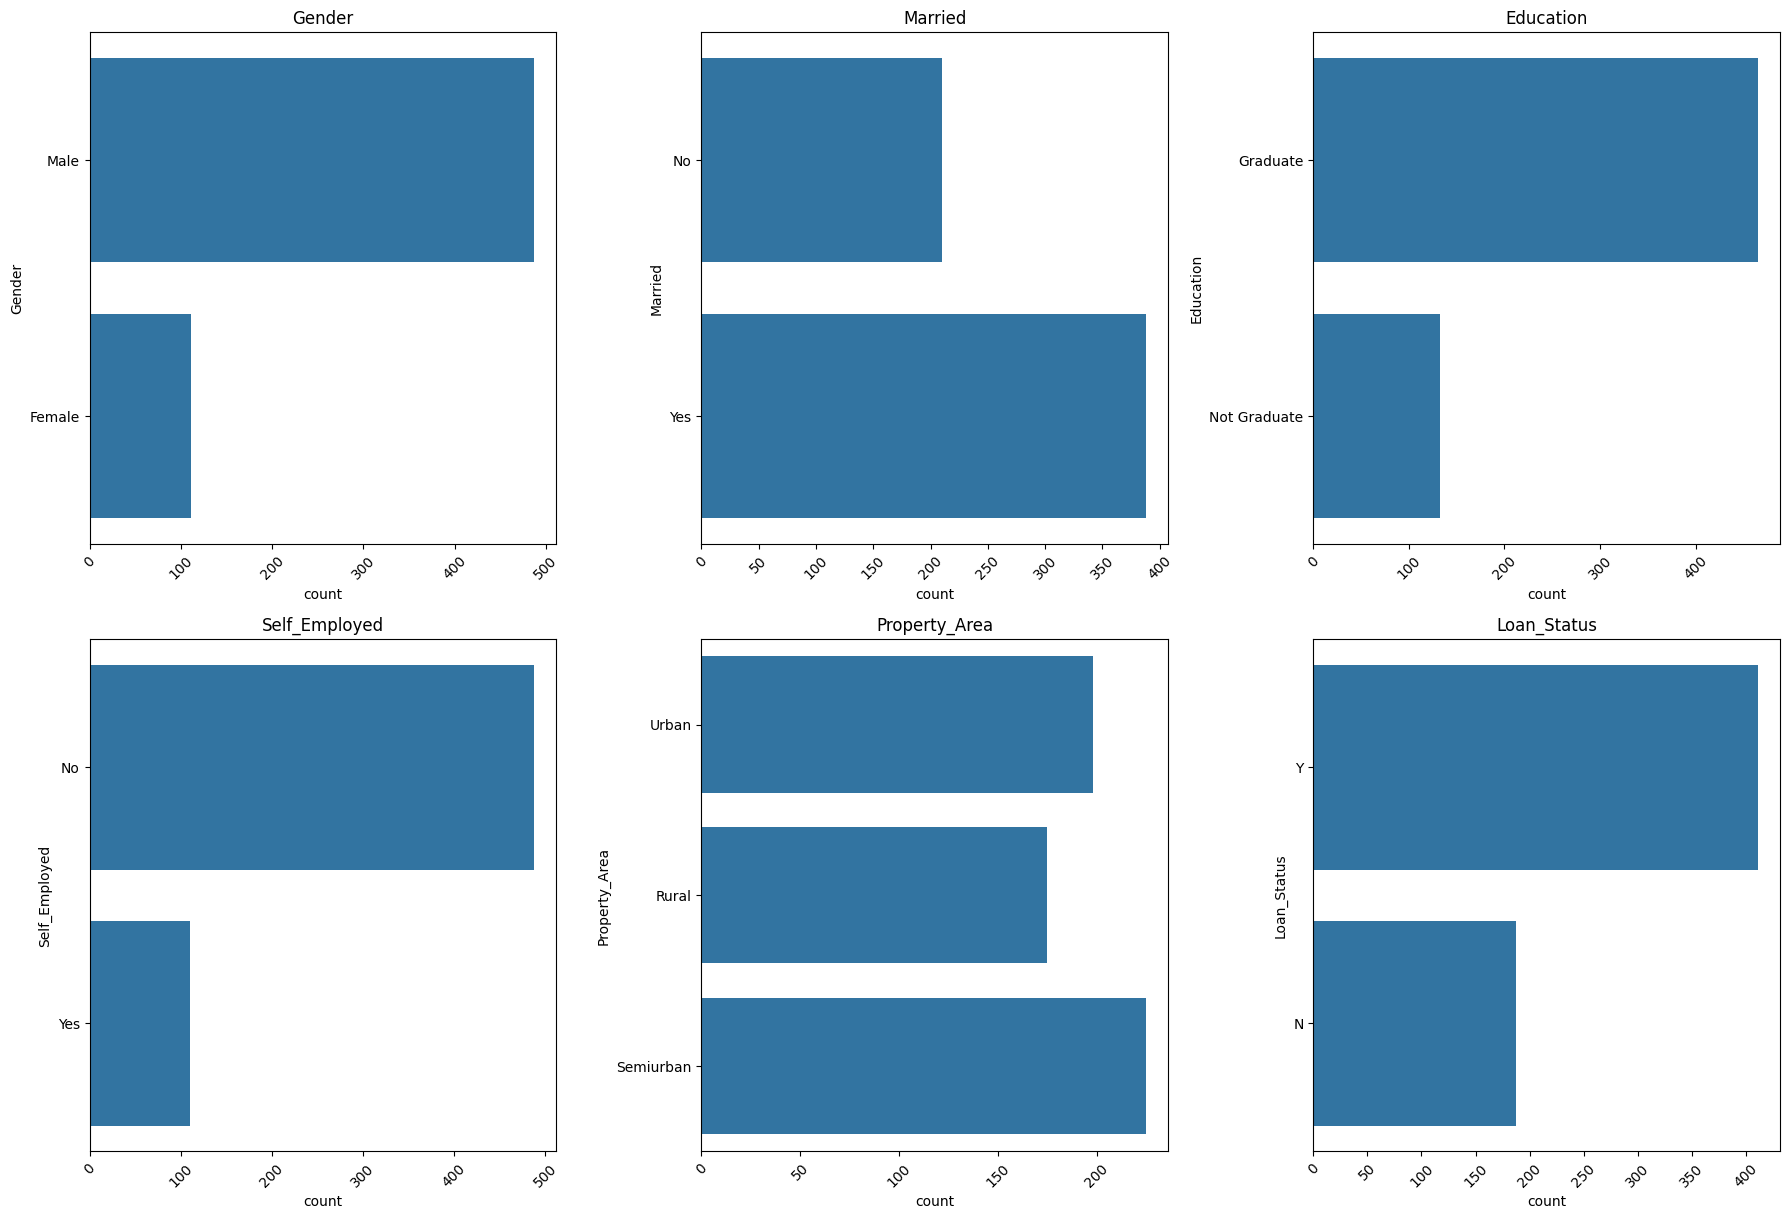

In [5]:
# Visualize categorical distributions
plt.figure(figsize=(18, 36))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(6, 3, i)
    sns.countplot(data[col])
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [6]:
# Label encoding categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

# Null value check
print("\nMissing values before filling:\n", data.isnull().sum())




Missing values before filling:
 Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64


In [7]:
# Fill missing values with mean (simple approach)
data.fillna(data.mean(numeric_only=True), inplace=True)

# Double-check missing values
print("\nMissing values after filling:\n", data.isnull().sum())




Missing values after filling:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


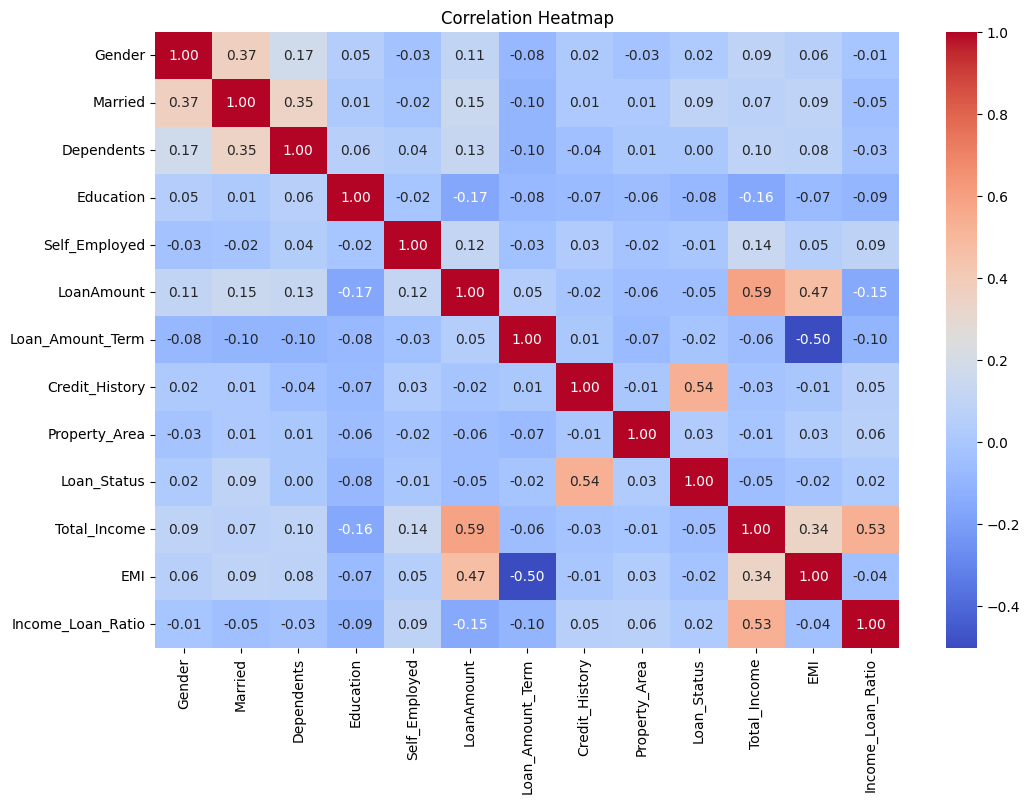

In [8]:
# Feature Engineering: Add Total_Income & EMI
data['Total_Income'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data['EMI'] = data['LoanAmount'] / data['Loan_Amount_Term']
#Income Loan Ratio
data['Income_Loan_Ratio'] = data['Total_Income'] / data['LoanAmount']


# Drop original income features if needed
data.drop(columns=['ApplicantIncome', 'CoapplicantIncome'], inplace=True)

# Heatmap for correlation
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



In [9]:
# Define input and target
X = data.drop('Loan_Status', axis=1)
y= data['Loan_Status']

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [10]:
# Handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After:", Counter(y_train_res))


Before: Counter({1: 287, 0: 131})
After: Counter({1: 287, 0: 287})


In [11]:
# Define classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

classifiers = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(probability=True),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print("\n", name)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))



 Logistic Regression
              precision    recall  f1-score   support

           0       0.60      0.57      0.59        56
           1       0.81      0.83      0.82       124

    accuracy                           0.75       180
   macro avg       0.71      0.70      0.70       180
weighted avg       0.75      0.75      0.75       180

ROC-AUC: 0.7178859447004609

 Random Forest
              precision    recall  f1-score   support

           0       0.69      0.55      0.61        56
           1       0.81      0.89      0.85       124

    accuracy                           0.78       180
   macro avg       0.75      0.72      0.73       180
weighted avg       0.78      0.78      0.78       180

ROC-AUC: 0.7727534562211981

 SVM
              precision    recall  f1-score   support

           0       0.46      0.11      0.17        56
           1       0.70      0.94      0.80       124

    accuracy                           0.68       180
   macro avg       0.58     

In [13]:
## This block finds the best Random Forest parameters using GridSearchCV.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 10, 'n_estimators': 100}


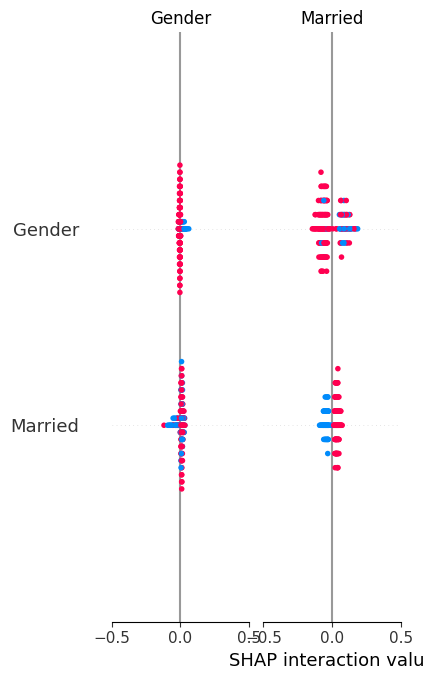

In [19]:
# This block uses SHAP to interpret the Random Forest model by analyzing feature contributions to predictions.
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
